In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn import metrics
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.tree import DecisionTreeClassifier,plot_tree
print('Libraries imported')

Libraries imported


In [10]:
df=pd.read_csv('./winequality.csv')
df.info

<bound method DataFrame.info of       fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0               7.4             0.700         0.00             1.9      0.076   
1               7.8             0.880         0.00             2.6      0.098   
2               7.8             0.760         0.04             2.3      0.092   
3              11.2             0.280         0.56             1.9      0.075   
4               7.4             0.700         0.00             1.9      0.076   
...             ...               ...          ...             ...        ...   
1138            6.3             0.510         0.13             2.3      0.076   
1139            6.8             0.620         0.08             1.9      0.068   
1140            6.2             0.600         0.08             2.0      0.090   
1141            5.9             0.550         0.10             2.2      0.062   
1142            5.9             0.645         0.12             2.0      0.075

In [11]:
df.head(10)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4
5,7.4,0.66,0.00,1.8,0.075,13.0,40.0,0.9978,3.51,0.56,9.4,5,5
6,7.9,0.60,0.06,1.6,0.069,15.0,59.0,0.9964,3.30,0.46,9.4,5,6
7,7.3,0.65,0.00,1.2,0.065,15.0,21.0,0.9946,3.39,0.47,10.0,7,7
8,7.8,0.58,0.02,2.0,0.073,9.0,18.0,0.9968,3.36,0.57,9.5,7,8
9,6.7,0.58,0.08,1.8,0.097,15.0,65.0,0.9959,3.28,0.54,9.2,5,10


In [12]:
df.isnull().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
Id                      0
dtype: int64

In [13]:
df.isnull().sum().sum()

0

In [14]:
X=df.drop('quality',axis=1)
y=df['quality']

In [21]:
x=df.drop('quality',axis=1)
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)
dt = DecisionTreeClassifier()
params = {
    'criterion':['gini','entropy'],
    'max_depth':[2,3,4,5],
    'min_samples_split':[2,5,10]
}
grid = GridSearchCV(estimator=dt,param_grid=params,cv=5)
grid.fit(X_train,y_train)
 
model = grid.best_estimator_
 
print("BEST PARAMETERS")
print(grid.best_params_)

BEST PARAMETERS
{'criterion': 'entropy', 'max_depth': 5, 'min_samples_split': 5}


In [22]:
y_pred=model.predict(X_test)
print(f'Accuracy score : {metrics.accuracy_score(y_test,y_pred)}')

Accuracy score : 0.5589519650655022


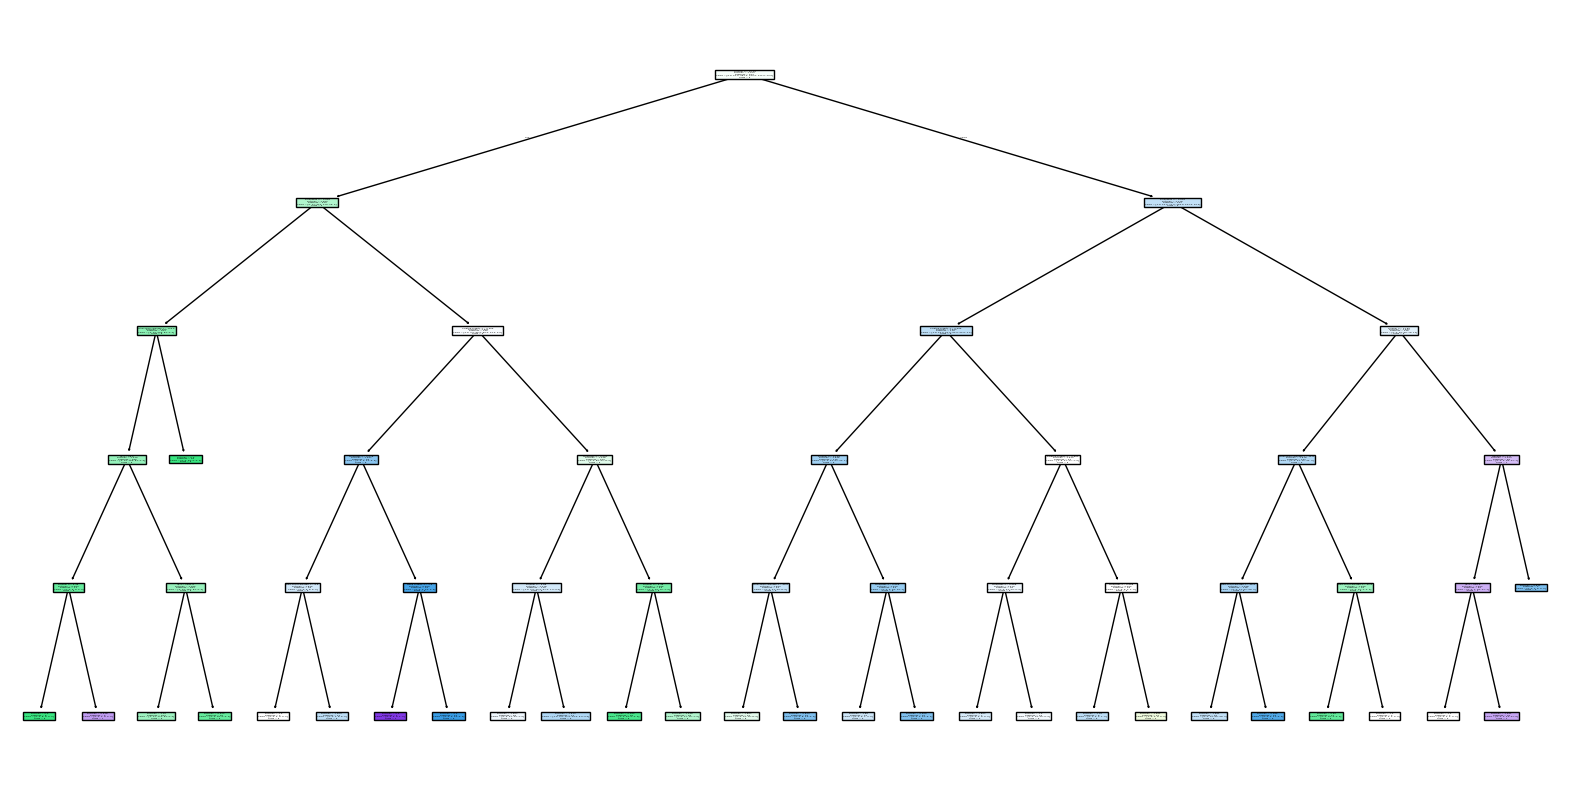

In [23]:
plt.figure(figsize=(20,10))
plot_tree(
    model,
    filled=True,
    feature_names=X_train.columns,
    class_names=[str(i) for i in model.classes_]
)
plt.show()

In [24]:
# Feature Importance
importances = model.feature_importances_

feature_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': importances
})

feature_df = feature_df.sort_values(
    by='Importance',
    ascending=False
)

print("Feature Importance:")
print(feature_df)

Feature Importance:
                 Feature  Importance
10               alcohol    0.415721
9              sulphates    0.156193
1       volatile acidity    0.108452
4              chlorides    0.090699
6   total sulfur dioxide    0.078902
11                    Id    0.068123
5    free sulfur dioxide    0.058215
7                density    0.013842
0          fixed acidity    0.009854
2            citric acid    0.000000
3         residual sugar    0.000000
8                     pH    0.000000
